Solution using Cramer's Rule: x = 2.00, y = 3.00, z = -1.00


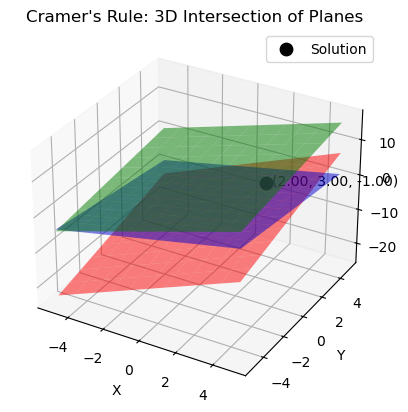

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Cramer's Rule
# -----------------------------
def cramers_rule(A, b):
    det_A = np.linalg.det(A)
    if det_A == 0:
        raise ValueError("System has no unique solution (determinant = 0).")
    
    n = A.shape[1]
    solution = []
    
    for i in range(n):
        Ai = A.copy()
        Ai[:, i] = b
        solution.append(np.linalg.det(Ai) / det_A)
    
    return np.array(solution)

# -----------------------------
# Example System
# -----------------------------
A = np.array([[2, 1, -1],
              [-3, -1, 2],
              [-2, 1, 2]], dtype=float)

b = np.array([8, -11, -3], dtype=float)

solution = cramers_rule(A, b)
x, y, z = solution
print(f"Solution using Cramer's Rule: x = {x:.2f}, y = {y:.2f}, z = {z:.2f}")

# -----------------------------
# Visualization
# -----------------------------
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Create mesh grid for planes
xx, yy = np.meshgrid(range(-5, 6), range(-5, 6))

# Plane equations
z1 = 2*xx + yy - 8
z2 = (3*xx + yy + 11) / 2
z3 = (2*xx - yy - 3) / 2

# Plot planes
ax.plot_surface(xx, yy, z1, alpha=0.5, color='red')
ax.plot_surface(xx, yy, z2, alpha=0.5, color='green')
ax.plot_surface(xx, yy, z3, alpha=0.5, color='blue')

# Mark solution
ax.scatter(x, y, z, color='black', s=80, label='Solution')
ax.text(x+0.3, y, z, f"({x:.2f}, {y:.2f}, {z:.2f})", color='black')

# Labels
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title("Cramer's Rule: 3D Intersection of Planes")
ax.legend()

plt.show()
